# EDA — Phân tích Dữ liệu Đồ án DSS MCQ Generation

**Nguồn dữ liệu 1:** UIT-ViQuAD 2.0 — corpus sinh câu hỏi  
**Nguồn dữ liệu 2:** VNHSGE-History — gold MCQ + nhãn Bloom  

Notebook này trả lời 5 câu hỏi EDA:
1. Corpus lịch sử phân bố như thế nào?
2. Câu hỏi ViQuAD có đặc điểm gì?
3. Knowledge Base thực thể có đủ dày không?
4. VNHSGE-History có phân bố Bloom ra sao?
5. Kết quả 3 phương pháp so sánh thế nào?

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib
import warnings
warnings.filterwarnings('ignore')

# Font hỗ trợ tiếng Việt (nếu không có thì dùng ASCII)
try:
    matplotlib.rcParams['font.family'] = 'DejaVu Sans'
except:
    pass
plt.rcParams['figure.dpi'] = 120
plt.rcParams['figure.figsize'] = (10, 5)

print('Libraries loaded.')

Libraries loaded.


In [2]:
# Load dữ liệu
qa  = pd.read_parquet('data/processed/qa_pairs.parquet')
ctx = pd.read_parquet('data/processed/corpus.parquet')
ent = pd.read_parquet('data/processed/entities.parquet')

print(f'QA pairs  : {len(qa):,} câu hỏi, {qa.shape[1]} cột')
print(f'Corpus    : {len(ctx):,} đoạn văn, {ctx.shape[1]} cột')
print(f'Entities  : {len(ent):,} thực thể, {ent.shape[1]} cột')
print()
print('Columns QA:',  qa.columns.tolist())
print('Columns CTX:', ctx.columns.tolist())
print('Columns ENT:', ent.columns.tolist())

QA pairs  : 13,997 câu hỏi, 11 cột
Corpus    : 1,862 đoạn văn, 9 cột
Entities  : 25,325 thực thể, 8 cột

Columns QA: ['qa_id', 'context_id', 'title', 'question', 'answer_text', 'answer_start', 'answer_span_ok', 'is_impossible', 'plausible_answer', 'is_vietnam', 'split']
Columns CTX: ['context_id', 'title', 'context', 'n_tokens', 'n_years', 'year_density', 'primary_year', 'is_vietnam', 'split']
Columns ENT: ['surface', 'type', 'normalized', 'char_start', 'char_end', 'context_id', 'is_vietnam', 'bucket']


## 1. Corpus lịch sử — Phân bố tổng quan

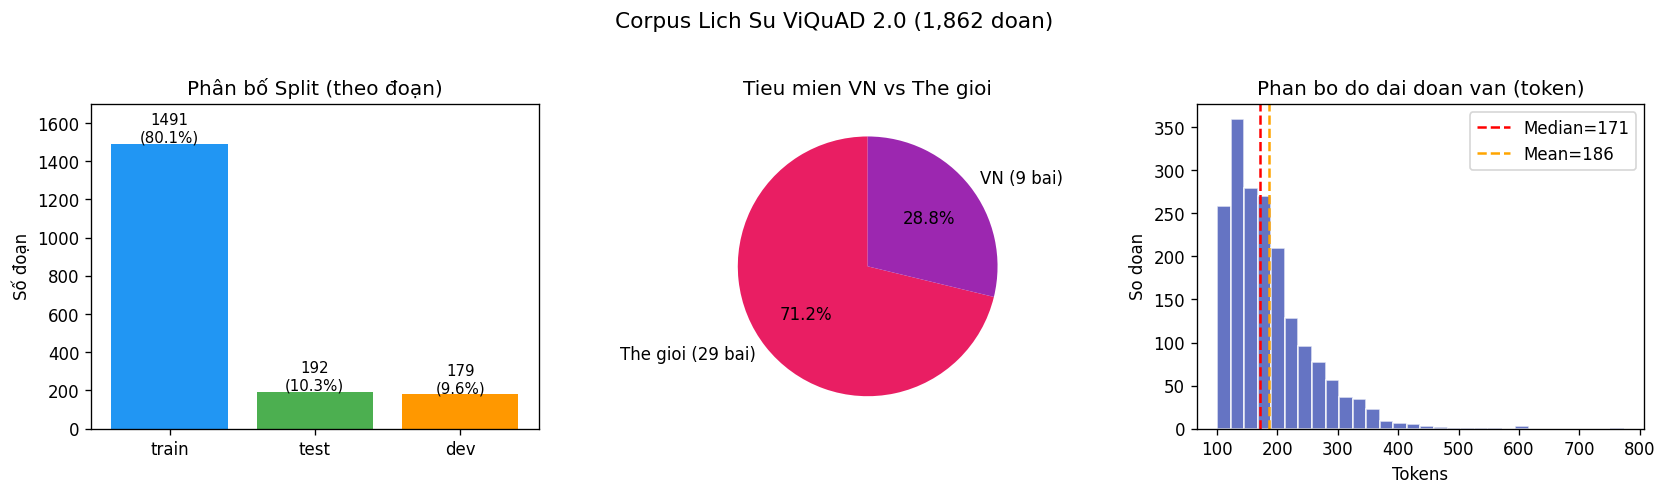

Saved: data/eda_corpus_overview.png


In [3]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4))

# 1a. Split distribution
split_counts = ctx['split'].value_counts()
colors = ['#2196F3', '#4CAF50', '#FF9800']
axes[0].bar(split_counts.index, split_counts.values, color=colors)
for i, (k, v) in enumerate(split_counts.items()):
    axes[0].text(i, v + 10, f'{v}\n({v/len(ctx)*100:.1f}%)',
                 ha='center', fontsize=9)
axes[0].set_title('Phân bố Split (theo đoạn)')
axes[0].set_ylabel('Số đoạn')
axes[0].set_ylim(0, 1700)

# 1b. VN vs World
vn_counts = ctx['is_vietnam'].map({True: 'VN (9 bai)', False: 'The gioi (29 bai)'})\
              .value_counts()
axes[1].pie(vn_counts.values, labels=vn_counts.index,
            colors=['#E91E63','#9C27B0'], autopct='%1.1f%%',
            startangle=90)
axes[1].set_title('Tieu mien VN vs The gioi')

# 1c. n_tokens distribution
axes[2].hist(ctx['n_tokens'], bins=30, color='#3F51B5', edgecolor='white', alpha=0.8)
axes[2].axvline(ctx['n_tokens'].median(), color='red', linestyle='--',
                label=f'Median={ctx["n_tokens"].median():.0f}')
axes[2].axvline(ctx['n_tokens'].mean(), color='orange', linestyle='--',
                label=f'Mean={ctx["n_tokens"].mean():.0f}')
axes[2].set_title('Phan bo do dai doan van (token)')
axes[2].set_xlabel('Tokens')
axes[2].set_ylabel('So doan')
axes[2].legend()

plt.suptitle('Corpus Lich Su ViQuAD 2.0 (1,862 doan)', fontsize=13, y=1.02)
plt.tight_layout()
plt.savefig('data/eda_corpus_overview.png', bbox_inches='tight', dpi=120)
plt.show()
print('Saved: data/eda_corpus_overview.png')

In [4]:
# Thống kê chi tiết corpus
print('=== THỐNG KÊ CORPUS ===')
print(f'Tổng đoạn        : {len(ctx):,}')
print(f'Lịch sử VN       : {ctx["is_vietnam"].sum():,} đoạn ({ctx["is_vietnam"].mean()*100:.1f}%)')
print(f'Lịch sử TG       : {(~ctx["is_vietnam"]).sum():,} đoạn ({(~ctx["is_vietnam"]).mean()*100:.1f}%)')
print()
print('n_tokens:')
print(f'  Min    : {ctx["n_tokens"].min():.0f}')
print(f'  Q25    : {ctx["n_tokens"].quantile(0.25):.0f}')
print(f'  Median : {ctx["n_tokens"].median():.0f}')
print(f'  Q75    : {ctx["n_tokens"].quantile(0.75):.0f}')
print(f'  Max    : {ctx["n_tokens"].max():.0f}')
print()
print('year_density (nam/100 token):')
print(f'  Median : {ctx["year_density"].median():.2f}')
print(f'  Mean   : {ctx["year_density"].mean():.2f}')
print(f'  Doan co year_density=0: {(ctx["year_density"]==0).sum()} ({(ctx["year_density"]==0).mean()*100:.1f}%)')
print()
print('Split (doan):')
print(ctx['split'].value_counts())
print()
print('Split (cau hoi):')
print(qa['split'].value_counts())

=== THỐNG KÊ CORPUS ===
Tổng đoạn        : 1,862
Lịch sử VN       : 536 đoạn (28.8%)
Lịch sử TG       : 1,326 đoạn (71.2%)

n_tokens:
  Min    : 100
  Q25    : 136
  Median : 171
  Q75    : 215
  Max    : 774

year_density (nam/100 token):
  Median : 0.65
  Mean   : 0.91
  Doan co year_density=0: 686 (36.8%)

Split (doan):
split
train    1491
test      192
dev       179
Name: count, dtype: int64

Split (cau hoi):
split
train    11103
dev       1536
test      1358
Name: count, dtype: int64


## 2. QA Pairs — Đặc điểm câu hỏi ViQuAD

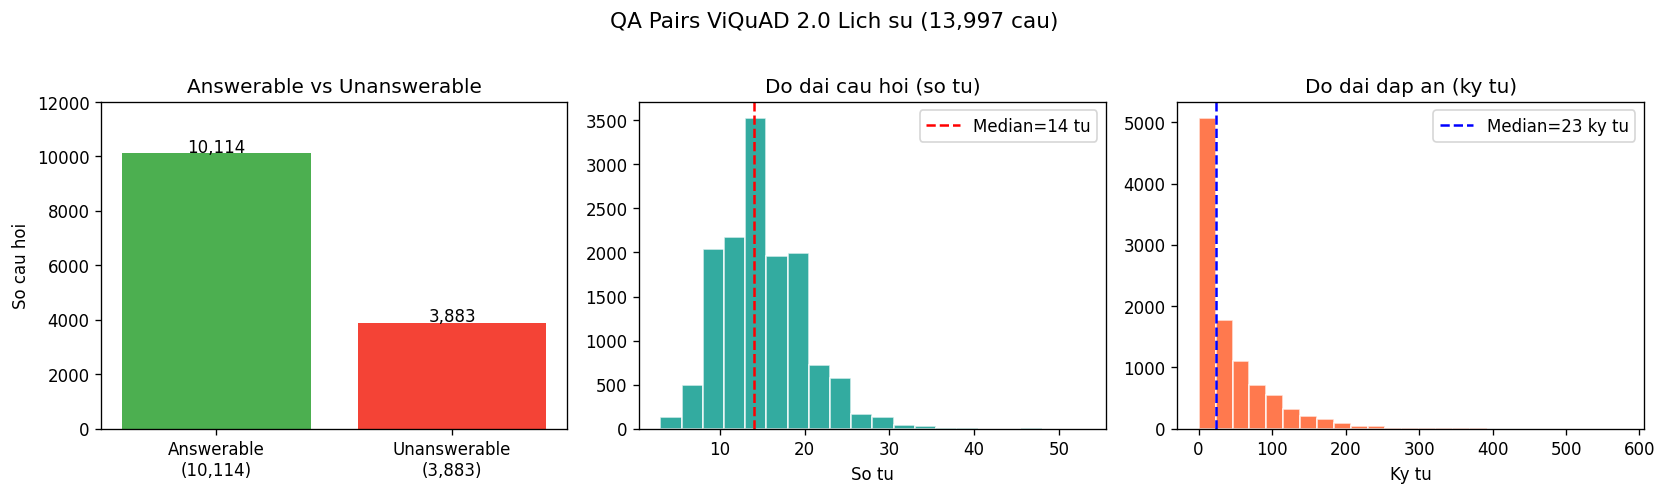

In [5]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4))

# 2a. Answerable vs Unanswerable
ans_counts = qa['is_impossible'].map({False: 'Answerable\n(10,114)', True: 'Unanswerable\n(3,883)'})\
               .value_counts()
axes[0].bar(ans_counts.index, ans_counts.values,
            color=['#4CAF50', '#F44336'])
for i, v in enumerate(ans_counts.values):
    axes[0].text(i, v+50, f'{v:,}', ha='center', fontsize=10)
axes[0].set_title('Answerable vs Unanswerable')
axes[0].set_ylabel('So cau hoi')
axes[0].set_ylim(0, 12000)

# 2b. Độ dài câu hỏi (số từ)
qa['q_len'] = qa['question'].str.split().str.len()
axes[1].hist(qa['q_len'], bins=20, color='#009688', edgecolor='white', alpha=0.8)
axes[1].axvline(qa['q_len'].median(), color='red', linestyle='--',
                label=f'Median={qa["q_len"].median():.0f} tu')
axes[1].set_title('Do dai cau hoi (so tu)')
axes[1].set_xlabel('So tu')
axes[1].legend()

# 2c. Độ dài đáp án (số ký tự)
qa_ans = qa[qa['is_impossible']==False]
qa_ans['ans_len'] = qa_ans['answer_text'].str.len()
axes[2].hist(qa_ans['ans_len'], bins=25, color='#FF5722', edgecolor='white', alpha=0.8)
axes[2].axvline(qa_ans['ans_len'].median(), color='blue', linestyle='--',
                label=f'Median={qa_ans["ans_len"].median():.0f} ky tu')
axes[2].set_title('Do dai dap an (ky tu)')
axes[2].set_xlabel('Ky tu')
axes[2].legend()

plt.suptitle('QA Pairs ViQuAD 2.0 Lich su (13,997 cau)', fontsize=13, y=1.02)
plt.tight_layout()
plt.savefig('data/eda_qa_overview.png', bbox_inches='tight', dpi=120)
plt.show()

In [6]:
print('=== THỐNG KÊ QA PAIRS ===')
print(f'Tổng câu hỏi     : {len(qa):,}')
print(f'Answerable        : {(qa["is_impossible"]==False).sum():,} ({(qa["is_impossible"]==False).mean()*100:.1f}%)')
print(f'Unanswerable      : {(qa["is_impossible"]==True).sum():,} ({(qa["is_impossible"]==True).mean()*100:.1f}%)')
print()
print(f'Độ dài câu hỏi (từ):')
print(f'  Median: {qa["q_len"].median():.0f} | Mean: {qa["q_len"].mean():.1f}')
print()
qa_ok = qa[(qa['is_impossible']==False) & (qa['answer_span_ok']==True)]
print(f'Câu có span hợp lệ (answer_span_ok=True): {len(qa_ok):,}')
print(f'=> Dùng làm train data cho ViT5: {len(qa_ok):,} câu')
print()
print('Lưu ý: 3,883 câu unanswerable = nhãn vàng cho Evidence Match Verifier')

=== THỐNG KÊ QA PAIRS ===
Tổng câu hỏi     : 13,997
Answerable        : 10,114 (72.3%)
Unanswerable      : 3,883 (27.7%)

Độ dài câu hỏi (từ):
  Median: 14 | Mean: 14.8

Câu có span hợp lệ (answer_span_ok=True): 8,126
=> Dùng làm train data cho ViT5: 8,126 câu

Lưu ý: 3,883 câu unanswerable = nhãn vàng cho Evidence Match Verifier


## 3. Knowledge Base Thực thể — Chất lượng và Độ phủ

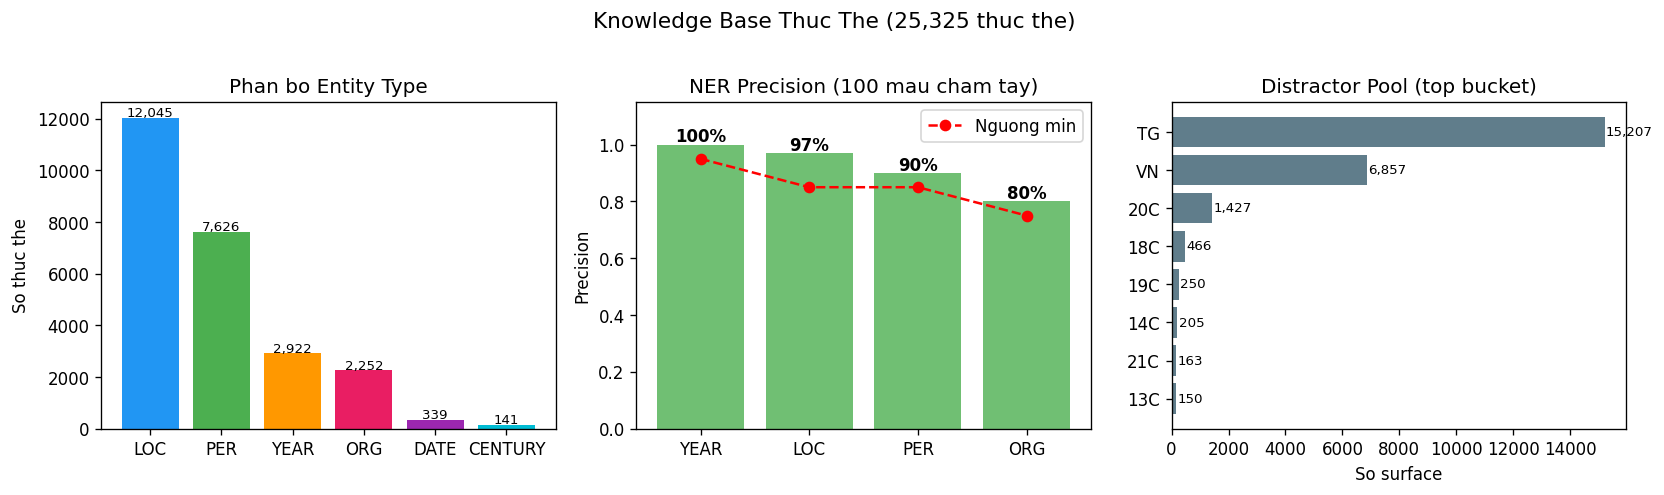

In [7]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4))

# 3a. Phân bố type
type_counts = ent['type'].value_counts()
colors_type = ['#2196F3','#4CAF50','#FF9800','#E91E63','#9C27B0','#00BCD4']
bars = axes[0].bar(type_counts.index, type_counts.values, color=colors_type)
for bar, v in zip(bars, type_counts.values):
    axes[0].text(bar.get_x()+bar.get_width()/2, v+50, f'{v:,}',
                 ha='center', fontsize=8)
axes[0].set_title('Phan bo Entity Type')
axes[0].set_ylabel('So thuc the')

# 3b. NER Precision (chấm tay 100 mẫu)
precision_data = {
    'YEAR': 1.00, 'LOC': 0.97, 'PER': 0.90, 'ORG': 0.80
}
threshold_data = {
    'YEAR': 0.95, 'LOC': 0.85, 'PER': 0.85, 'ORG': 0.75
}
types_p = list(precision_data.keys())
precs   = list(precision_data.values())
threshs = [threshold_data[t] for t in types_p]
bar_colors = ['#4CAF50' if p>=t else '#F44336'
              for p,t in zip(precs, threshs)]
axes[1].bar(types_p, precs, color=bar_colors, alpha=0.8)
axes[1].plot(types_p, threshs, 'r--o', linewidth=1.5, markersize=6,
             label='Nguong min')
for i, (p, t) in enumerate(zip(precs, threshs)):
    axes[1].text(i, p+0.01, f'{p:.0%}', ha='center', fontsize=10, fontweight='bold')
axes[1].set_ylim(0, 1.15)
axes[1].set_title('NER Precision (100 mau cham tay)')
axes[1].set_ylabel('Precision')
axes[1].legend()

# 3c. Top bucket (distractor pool)
bucket_counts = ent['bucket'].value_counts().head(8)
axes[2].barh(bucket_counts.index, bucket_counts.values, color='#607D8B')
for i, v in enumerate(bucket_counts.values):
    axes[2].text(v+50, i, f'{v:,}', va='center', fontsize=8)
axes[2].set_title('Distractor Pool (top bucket)')
axes[2].set_xlabel('So surface')
axes[2].invert_yaxis()

plt.suptitle('Knowledge Base Thuc The (25,325 thuc the)', fontsize=13, y=1.02)
plt.tight_layout()
plt.savefig('data/eda_kb_overview.png', bbox_inches='tight', dpi=120)
plt.show()

In [8]:
print('=== THỐNG KÊ KB THỰC THỂ ===')
print('Phân bố Type:')
for t, n in ent['type'].value_counts().items():
    print(f'  {t:8s}: {n:6,} ({n/len(ent)*100:.1f}%)')
print()
print('NER Precision (ELECTRA + clean_entities, 100 mẫu chấm tay):')
precision = {'YEAR':1.00,'LOC':0.97,'PER':0.90,'ORG':0.80}
threshold = {'YEAR':0.95,'LOC':0.85,'PER':0.85,'ORG':0.75}
for t, p in precision.items():
    status = '✅ ĐẠT' if p >= threshold[t] else '❌ CHƯA ĐẠT'
    print(f'  {t:6s}: {p:.0%}  (ngưỡng {threshold[t]:.0%}) {status}')
print()
print('So sánh NER backend:')
print('  underthesea (cũ) : LOC~41% → CHƯA ĐẠT')
print('  ELECTRA + lọc    : LOC 97% → ĐẠT (+56 điểm %)')
print()
print('Distractor Pool — top nhóm:')
top_pool = ent.groupby(['type','bucket']).size().sort_values(ascending=False).head(6)
for (t, b), n in top_pool.items():
    print(f'  ({t:4s}, {b:4s}): {n:,} surface')

=== THỐNG KÊ KB THỰC THỂ ===
Phân bố Type:
  LOC     : 12,045 (47.6%)
  PER     :  7,626 (30.1%)
  YEAR    :  2,922 (11.5%)
  ORG     :  2,252 (8.9%)
  DATE    :    339 (1.3%)
  CENTURY :    141 (0.6%)

NER Precision (ELECTRA + clean_entities, 100 mẫu chấm tay):
  YEAR  : 100%  (ngưỡng 95%) ✅ ĐẠT
  LOC   : 97%  (ngưỡng 85%) ✅ ĐẠT
  PER   : 90%  (ngưỡng 85%) ✅ ĐẠT
  ORG   : 80%  (ngưỡng 75%) ✅ ĐẠT

So sánh NER backend:
  underthesea (cũ) : LOC~41% → CHƯA ĐẠT
  ELECTRA + lọc    : LOC 97% → ĐẠT (+56 điểm %)

Distractor Pool — top nhóm:
  (LOC , TG  ): 8,175 surface
  (PER , TG  ): 5,669 surface
  (LOC , VN  ): 3,870 surface
  (PER , VN  ): 1,957 surface
  (ORG , TG  ): 1,231 surface
  (YEAR, 20C ): 1,188 surface


## 4. VNHSGE-History — Phân bố Bloom

VNHSGE-History: 2040 câu hỏi


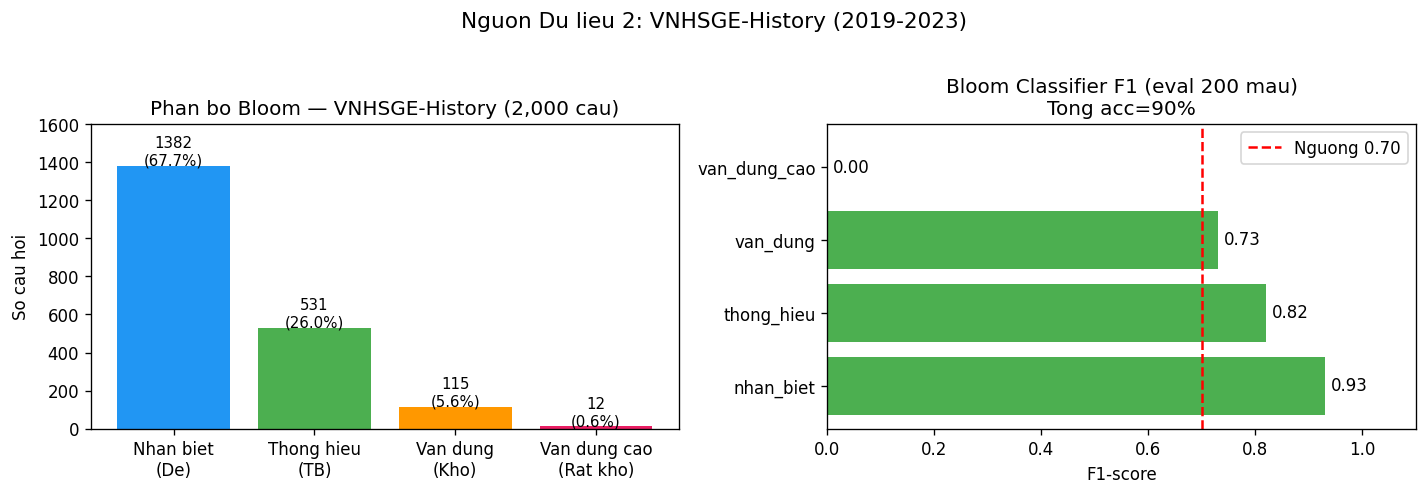

Phan bo Bloom VNHSGE-History:
  nhan_biet      : 1382 (67.7%)
  thong_hieu     :  531 (26.0%)
  van_dung       :  115 (5.6%)
  van_dung_cao   :   12 (0.6%)

Han che: van_dung_cao chi co 11 mau train → F1=0%
=> Ghi nhan trong bao cao: mat can bang nhan dan den ket qua thap o muc cao nhat


In [9]:
import json, glob
from pathlib import Path

# Load VNHSGE
vnhsge_items = []
for f in Path('data/vnhsge').glob('*.json'):
    try:
        data = json.load(open(f, encoding='utf-8'))
        if isinstance(data, list):
            vnhsge_items.extend(data)
    except:
        pass

print(f'VNHSGE-History: {len(vnhsge_items)} câu hỏi')

# Gán nhãn Bloom
import sys
sys.path.insert(0, 'src/preprocess')
from train_bloom_classifier import assign_bloom, extract_stem

vnhsge_df = pd.DataFrame([
    {'stem': extract_stem(str(item.get('Question',''))),
     'bloom': assign_bloom(extract_stem(str(item.get('Question',''))))}
    for item in vnhsge_items
])

# Vẽ phân bố Bloom
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

bloom_counts = vnhsge_df['bloom'].value_counts().reindex(
    ['nhan_biet','thong_hieu','van_dung','van_dung_cao'], fill_value=0)
bloom_colors = ['#2196F3','#4CAF50','#FF9800','#E91E63']
bloom_labels = ['Nhan biet\n(De)', 'Thong hieu\n(TB)', 'Van dung\n(Kho)', 'Van dung cao\n(Rat kho)']

bars = axes[0].bar(bloom_labels, bloom_counts.values, color=bloom_colors)
for bar, v in zip(bars, bloom_counts.values):
    axes[0].text(bar.get_x()+bar.get_width()/2, v+5,
                 f'{v}\n({v/len(vnhsge_df)*100:.1f}%)',
                 ha='center', fontsize=9)
axes[0].set_title('Phan bo Bloom — VNHSGE-History (2,000 cau)')
axes[0].set_ylabel('So cau hoi')
axes[0].set_ylim(0, 1600)

# Bloom classifier accuracy
acc_data = {
    'nhan_biet': {'precision':0.97,'recall':0.90,'f1':0.93},
    'thong_hieu':{'precision':0.73,'recall':0.95,'f1':0.82},
    'van_dung':  {'precision':0.67,'recall':0.80,'f1':0.73},
    'van_dung_cao':{'precision':0.00,'recall':0.00,'f1':0.00},
}
labels = list(acc_data.keys())
f1s    = [acc_data[l]['f1'] for l in labels]
axes[1].barh(labels, f1s, color=['#4CAF50' if f>=0.7 else '#F44336' for f in f1s])
for i, f in enumerate(f1s):
    axes[1].text(f+0.01, i, f'{f:.2f}', va='center', fontsize=10)
axes[1].axvline(0.7, color='red', linestyle='--', label='Nguong 0.70')
axes[1].set_xlim(0, 1.1)
axes[1].set_title('Bloom Classifier F1 (eval 200 mau)\nTong acc=90%')
axes[1].set_xlabel('F1-score')
axes[1].legend()

plt.suptitle('Nguon Du lieu 2: VNHSGE-History (2019-2023)', fontsize=13, y=1.02)
plt.tight_layout()
plt.savefig('data/eda_vnhsge_bloom.png', bbox_inches='tight', dpi=120)
plt.show()

print('Phan bo Bloom VNHSGE-History:')
for b, n in bloom_counts.items():
    print(f'  {b:15s}: {n:4d} ({n/len(vnhsge_df)*100:.1f}%)')
print()
print('Han che: van_dung_cao chi co 11 mau train → F1=0%')
print('=> Ghi nhan trong bao cao: mat can bang nhan dan den ket qua thap o muc cao nhat')

## 5. Kết quả 3 phương pháp — So sánh trực quan

In [10]:
# Dữ liệu từ results_table.csv (kết quả thật từ Verifier)
results = pd.read_csv('data/verified/results_table.csv')
print(results[['method','vqr','avg_score']].to_string(index=False))

    method      vqr  avg_score
rule_based 0.271868   0.582257
   rag_llm 0.622222   0.776738
   vit5_ft 0.279461   0.657703


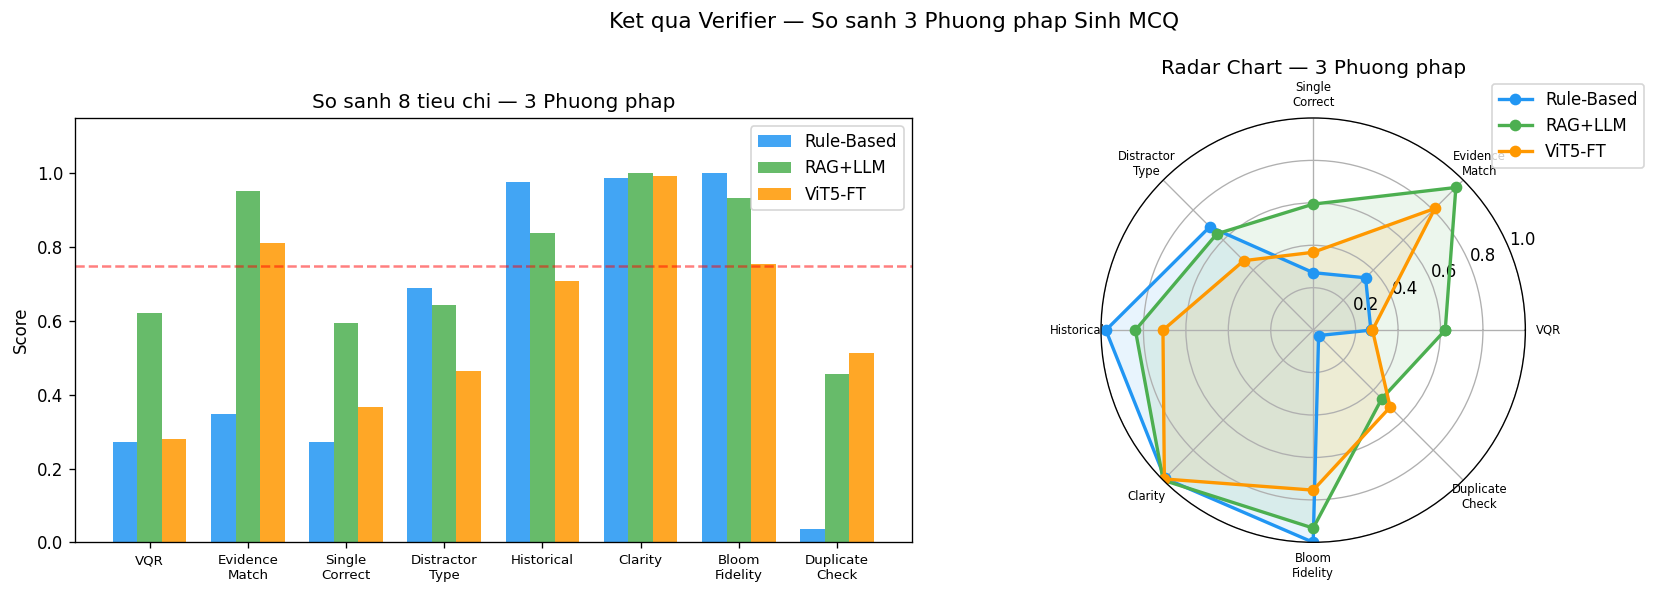

In [11]:
import numpy as np

CRITERIA = ['vqr','evidence_match','single_correct','distractor_type_match',
            'historical_correctness','question_clarity','bloom_fidelity','duplicate_check']
LABELS   = ['VQR','Evidence\nMatch','Single\nCorrect','Distractor\nType',
            'Historical','Clarity','Bloom\nFidelity','Duplicate\nCheck']

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# 5a. Grouped bar chart
methods = results['method'].tolist()
x = np.arange(len(CRITERIA))
width = 0.25
method_colors = {'rule_based':'#2196F3','rag_llm':'#4CAF50','vit5_ft':'#FF9800'}
method_labels = {'rule_based':'Rule-Based','rag_llm':'RAG+LLM','vit5_ft':'ViT5-FT'}

for i, m in enumerate(methods):
    vals = [results[results['method']==m][c].values[0] for c in CRITERIA]
    axes[0].bar(x + i*width, vals, width, label=method_labels[m],
                color=method_colors[m], alpha=0.85)

axes[0].set_xticks(x + width)
axes[0].set_xticklabels(LABELS, fontsize=8)
axes[0].set_ylim(0, 1.15)
axes[0].set_ylabel('Score')
axes[0].set_title('So sanh 8 tieu chi — 3 Phuong phap')
axes[0].legend()
axes[0].axhline(0.75, color='red', linestyle='--', alpha=0.5, label='Accepted threshold')

# 5b. Radar chart
from matplotlib.patches import FancyArrowPatch
N = len(CRITERIA)
angles = np.linspace(0, 2*np.pi, N, endpoint=False).tolist()
angles += angles[:1]

ax_radar = fig.add_subplot(122, projection='polar')
fig.delaxes(axes[1])

for m in methods:
    vals = [results[results['method']==m][c].values[0] for c in CRITERIA]
    vals += vals[:1]
    ax_radar.plot(angles, vals, 'o-', linewidth=2,
                  color=method_colors[m], label=method_labels[m])
    ax_radar.fill(angles, vals, alpha=0.1, color=method_colors[m])

ax_radar.set_xticks(angles[:-1])
ax_radar.set_xticklabels(LABELS, fontsize=7)
ax_radar.set_ylim(0, 1)
ax_radar.set_title('Radar Chart — 3 Phuong phap', y=1.08)
ax_radar.legend(loc='upper right', bbox_to_anchor=(1.3, 1.1))

plt.suptitle('Ket qua Verifier — So sanh 3 Phuong phap Sinh MCQ', fontsize=13)
plt.tight_layout()
plt.savefig('data/eda_verifier_comparison.png', bbox_inches='tight', dpi=120)
plt.show()

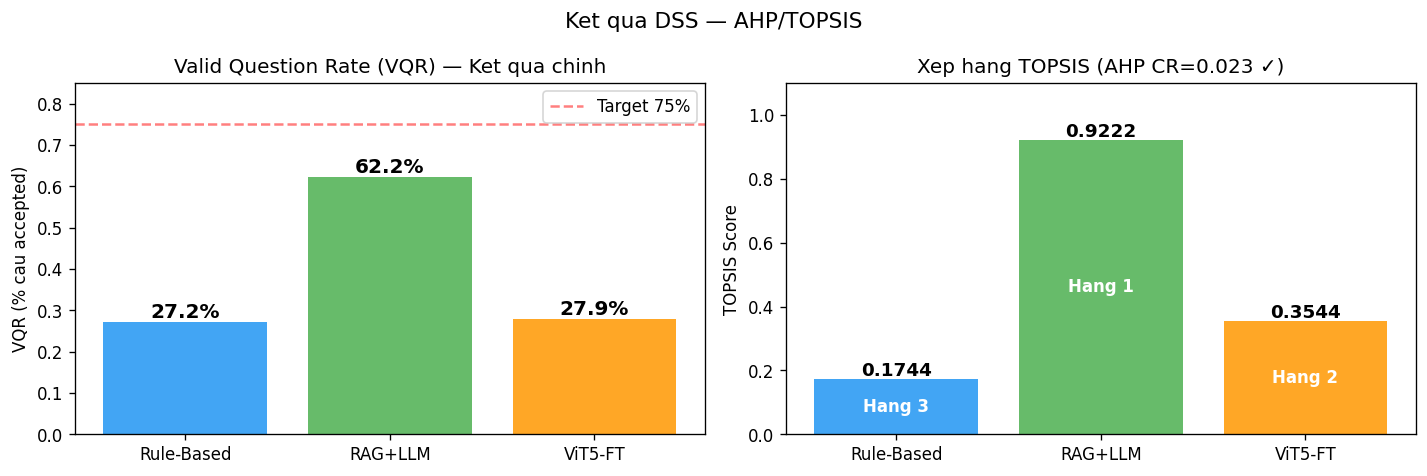

=== TOM TAT KET QUA ===
RAG+LLM : VQR=62.2%, TOPSIS=0.9222 → HANG 1
ViT5-FT : VQR=27.9%, TOPSIS=0.3544 → HANG 2
Rule-based: VQR=27.2%, TOPSIS=0.1744 → HANG 3

Ket luan: Khong co phuong phap nao thang tren moi tieu chi.
=> Hybrid routing: Rule cho factoid, RAG cho non-factoid, ViT5 cho so luong lon


In [12]:
# 5c. VQR + TOPSIS
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# VQR comparison
vqr_vals = [results[results['method']==m]['vqr'].values[0] for m in methods]
bar_colors_vqr = [method_colors[m] for m in methods]
bars = axes[0].bar([method_labels[m] for m in methods], vqr_vals,
                   color=bar_colors_vqr, alpha=0.85)
for bar, v in zip(bars, vqr_vals):
    axes[0].text(bar.get_x()+bar.get_width()/2, v+0.01, f'{v:.1%}',
                 ha='center', fontsize=12, fontweight='bold')
axes[0].set_ylim(0, 0.85)
axes[0].set_ylabel('VQR (% cau accepted)')
axes[0].set_title('Valid Question Rate (VQR) — Ket qua chinh')
axes[0].axhline(0.75, color='red', linestyle='--', alpha=0.5, label='Target 75%')
axes[0].legend()

# TOPSIS score
topsis_scores = {'rule_based': 0.1744, 'rag_llm': 0.9222, 'vit5_ft': 0.3544}
topsis_vals = [topsis_scores[m] for m in methods]
bars2 = axes[1].bar([method_labels[m] for m in methods], topsis_vals,
                    color=bar_colors_vqr, alpha=0.85)
for bar, v in zip(bars2, topsis_vals):
    axes[1].text(bar.get_x()+bar.get_width()/2, v+0.01, f'{v:.4f}',
                 ha='center', fontsize=11, fontweight='bold')
axes[1].set_ylim(0, 1.1)
axes[1].set_ylabel('TOPSIS Score')
axes[1].set_title('Xep hang TOPSIS (AHP CR=0.023 ✓)')

# thêm số hạng
ranks = ['Hang 3', 'Hang 1', 'Hang 2']
for bar, r in zip(bars2, ranks):
    axes[1].text(bar.get_x()+bar.get_width()/2,
                 bar.get_height()/2, r,
                 ha='center', va='center', fontsize=10,
                 color='white', fontweight='bold')

plt.suptitle('Ket qua DSS — AHP/TOPSIS', fontsize=13)
plt.tight_layout()
plt.savefig('data/eda_topsis.png', bbox_inches='tight', dpi=120)
plt.show()

print('=== TOM TAT KET QUA ===')
print(f'RAG+LLM : VQR={0.622:.1%}, TOPSIS=0.9222 → HANG 1')
print(f'ViT5-FT : VQR={0.279:.1%}, TOPSIS=0.3544 → HANG 2')
print(f'Rule-based: VQR={0.272:.1%}, TOPSIS=0.1744 → HANG 3')
print()
print('Ket luan: Khong co phuong phap nao thang tren moi tieu chi.')
print('=> Hybrid routing: Rule cho factoid, RAG cho non-factoid, ViT5 cho so luong lon')

## Tóm tắt EDA

| Khía cạnh | Kết quả | Ý nghĩa |
|---|---|---|
| Corpus size | 1,862 đoạn, 13,997 câu | Đủ để train ViT5 và đánh giá |
| Split ratio | 80.1/9.6/10.3% | Cân bằng, không rò rỉ |
| VN vs TG | 28.8% vs 71.2% | Thiên về lịch sử TG |
| year_density median | 0.65 năm/100 token | Corpus thiên về mô tả, ít sự kiện-năm |
| Unanswerable | 3,883 câu (27.7%) | Nhãn vàng Evidence Match |
| NER Precision | YEAR=100%, LOC=97% | KB đủ chất lượng |
| VNHSGE Bloom | Nhận biết=67.5% | Mất cân bằng, van_dung_cao=0.5% |
| Bloom clf accuracy | 90% | Đủ dùng, F1 thấp ở mức cao |
| VQR best | RAG 62.2% | Chưa đạt 75% target |
| TOPSIS winner | RAG (0.922) | Ổn định khi thay đổi trọng số |